# 13_核方法-核函数

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿和大家聊聊**核函数**\~

**核函数（Kernel Function）**主要用于将数据从原来的低维空间映射到一个更高维度的空间中，从而使得在高维空间中可以更容易地找到线性分割的决策边界。

这种技术在支持向量机（SVM）等机器学习算法中非常常见。

一个非常简单的解释：核函数是一个函数 $K(x, y)$，它接受两个输入（通常是向量形式），并输出它们在某个高维特征空间中的内积。换句话说，核函数可以计算在这个高维空间中，两个点之间的“相似性”或“关系”。

假设你有一堆数据点，它们的分布比较复杂，在二维平面上（例如纸上）用直线很难把它们分开。核函数的作用就像一个魔法，把这些数据点“变形”到一个更高维的空间（比如从二维平面变到三维空间），在这个高维空间里，这些数据点可能就变得很容易用一个平面（相当于二维平面里的直线）分开了。

这样一来，你不用真的去算出高维空间的数据，而是通过核函数直接在原来的维度上做一些计算，就好像数据已经在高维空间里一样。

简言之，核函数让复杂的数据变得可以被简单的方法（比如直线或平面）来分类。

![原文参考图，当前结果见代码输出](attachments/img_010.png)

## 理论基础

核函数（Kernel Functions）是支持向量机（SVM）、高斯过程（Gaussian Processes）等机器学习算法中的核心概念之一。

它们使得算法能够在高维甚至无限维的特征空间中进行操作，而不需要显式地计算特征映射。这种技术被称为“核技巧”（Kernel Trick）。

### 一、核函数的数学原理

#### 1.1 核函数的定义

核函数 $K(x, x')$是一个定义在输入空间的两个样本 $x$和 $x'$之间的函数，其定义为：


$$
K(x, x') = \langle \phi(x), \phi(x') \rangle
$$


其中， $\phi(x)$是将输入样本 $x$从原始空间映射到一个高维（甚至无限维）特征空间的映射函数，而 $\langle \cdot, \cdot \rangle$表示特征空间中的内积。

#### 1.2 核技巧

在机器学习问题中，计算映射到高维特征空间后的内积可能非常昂贵或不可行。然而，通过核技巧，我们可以直接在原始空间计算内积，而无需显式地计算映射。也就是说，核函数 $K(x, x')$能够直接给出在高维特征空间中的内积值，而不需要实际计算 $\phi(x)$和 $\phi(x')$。

#### 1.3 常见的核函数

1. **线性核**：  
$K(x, x') = \langle x, x' \rangle$  
这是最简单的核函数，对应于不进行任何映射的情况。
2. **多项式核**：  
$K(x, x') = (\langle x, x' \rangle + c)^d$  
其中 $c$和 $d$是超参数。该核函数对应于将输入空间映射到一个多项式特征空间。
3. **高斯径向基核（RBF）**：  
$K(x, x') = \exp\left(-\frac{\|x - x'\|^2}{2\sigma^2}\right)$  
其中 $\sigma$是超参数。高斯RBF核对应于将输入映射到一个无限维的特征空间。
4. **拉普拉斯核**：  
$K(x, x') = \exp\left(-\frac{\|x - x'\|}{\sigma}\right)$  
也是一种常见的径向基函数核，与高斯RBF核相似，但具有不同的衰减行为。

### 二、核函数的算法流程

#### 2.1 支持向量机（SVM）中的核函数使用

支持向量机的目标是找到一个决策边界，使得边界到两类样本的最近点的距离最大化。

在线性SVM中，这相当于找到最优的超平面：


$$
f(x) = \langle w, x \rangle + b = 0
$$


其中，$w$是法向量，$b$是偏置。

在非线性SVM中，我们使用核函数来处理非线性分类问题：

1. **数据映射**：使用映射函数 $\phi(x)$将输入数据 $x$映射到高维特征空间。
2. **构建拉格朗日函数**：构造基于映射数据的拉格朗日函数。
3. **计算内积**：在优化过程中，内积 $\langle \phi(x), \phi(x') \rangle$被核函数 $K(x, x')$替代。
4. **求解优化问题**：利用核函数的定义，求解相应的对偶问题，最终得到支持向量和决策函数。

优化问题的最终形式为：


$$
\min_{\alpha} \frac{1}{2} \sum_{i=1}^n \sum_{j=1}^n \alpha_i \alpha_j y_i y_j K(x_i, x_j) - \sum_{i=1}^n \alpha_i
$$


其中，$\alpha_i$是拉格朗日乘子，$y_i$是样本的标签。

最终的决策函数为：


$$
f(x) = \sum_{i=1}^n \alpha_i y_i K(x_i, x) + b
$$


#### 2.2 核函数的选取与调优

在实际应用中，核函数的选择对模型性能有很大影响。常见的流程如下：

1. **选择核函数类型**：根据数据特点，选择合适的核函数（如线性、多项式、高斯RBF等）。
2. **超参数调优**：通过交叉验证等方法调节核函数中的超参数（如高斯RBF中的 $\sigma$）。
3. **模型训练与评估**：使用选定的核函数和超参数训练模型，并评估其性能。

## 完整案例

咱们使用核函数（RBF 核）在支持向量机（SVM）中进行分类。咱们使用 `digits`，来自 `sklearn.datasets` 的 `digits` 数据集，它包含手写数字的图像

**1. 导入必要的库**

首先，我们需要导入必要的Python库。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

**2. 加载和准备数据**

使用 `digits` 数据集，它包含8x8像素的手写数字图像。

In [3]:
# 加载数据集
digits = datasets.load_digits()

# 数据集描述
print(digits.DESCR)

# 特征和目标
X = digits.data
y = digits.target

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 拆分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

**3. 建立支持向量机模型并使用RBF核**

使用SVM并应用RBF核函数进行分类。

In [4]:
# 初始化SVM模型
svc = SVC(kernel='rbf', random_state=42)

# 网格搜索进行超参数优化
param_grid = {
    'C': [0.1, 1],
    'gamma': [1, 0.1]
}

grid_search = GridSearchCV(svc, param_grid, refit=True, verbose=3, cv=5, n_jobs=1, error_score='raise')
grid_search.fit(X_train, y_train)

# 打印最佳参数
print(f"最佳参数: {grid_search.best_params_}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5] END ....................C=0.1, gamma=1;, score=0.099 total time=   0.1s
[CV 2/5] END ....................C=0.1, gamma=1;, score=0.119 total time=   0.1s
[CV 3/5] END ....................C=0.1, gamma=1;, score=0.108 total time=   0.1s


[CV 4/5] END ....................C=0.1, gamma=1;, score=0.120 total time=   0.1s
[CV 5/5] END ....................C=0.1, gamma=1;, score=0.100 total time=   0.1s
[CV 1/5] END ..................C=0.1, gamma=0.1;, score=0.266 total time=   0.1s


[CV 2/5] END ..................C=0.1, gamma=0.1;, score=0.306 total time=   0.1s
[CV 3/5] END ..................C=0.1, gamma=0.1;, score=0.331 total time=   0.1s
[CV 4/5] END ..................C=0.1, gamma=0.1;, score=0.299 total time=   0.1s
[CV 5/5] END ..................C=0.1, gamma=0.1;, score=0.291 total time=   0.1s


[CV 1/5] END ......................C=1, gamma=1;, score=0.115 total time=   0.1s
[CV 2/5] END ......................C=1, gamma=1;, score=0.151 total time=   0.1s
[CV 3/5] END ......................C=1, gamma=1;, score=0.135 total time=   0.1s
[CV 4/5] END ......................C=1, gamma=1;, score=0.179 total time=   0.1s


[CV 5/5] END ......................C=1, gamma=1;, score=0.116 total time=   0.1s
[CV 1/5] END ....................C=1, gamma=0.1;, score=0.917 total time=   0.1s
[CV 2/5] END ....................C=1, gamma=0.1;, score=0.909 total time=   0.1s


[CV 3/5] END ....................C=1, gamma=0.1;, score=0.948 total time=   0.1s
[CV 4/5] END ....................C=1, gamma=0.1;, score=0.920 total time=   0.1s
[CV 5/5] END ....................C=1, gamma=0.1;, score=0.940 total time=   0.1s


最佳参数: {'C': 1, 'gamma': 0.1}


**4. 模型评估与可视化**

使用最佳参数的模型进行预测，并评估其在测试集上的表现。

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        54
           1       0.96      0.96      0.96        55
           2       1.00      0.94      0.97        53
           3       0.98      0.98      0.98        55
           4       0.98      0.87      0.92        54
           5       0.65      0.98      0.78        55
           6       1.00      0.91      0.95        54
           7       1.00      0.94      0.97        54
           8       0.94      0.90      0.92        52
           9       0.98      0.89      0.93        54

    accuracy                           0.93       540
   macro avg       0.95      0.93      0.94       540
weighted avg       0.95      0.93      0.94       540



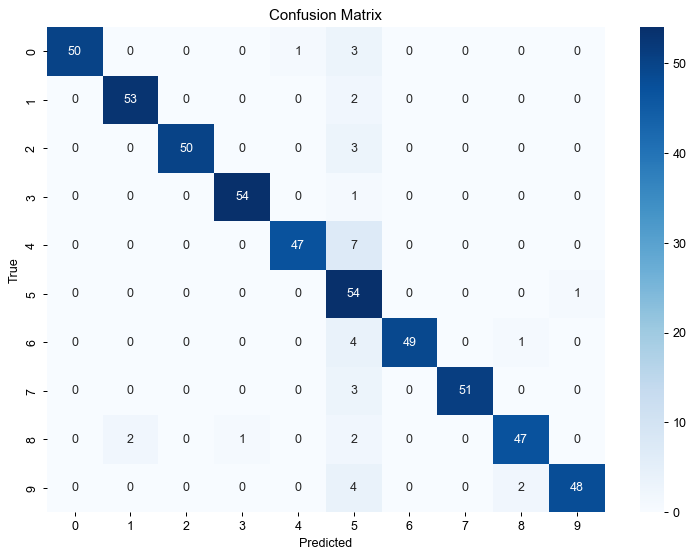

In [5]:
# 预测
y_pred = grid_search.predict(X_test)

# 打印分类报告
print(classification_report(y_test, y_pred))

# 混淆矩阵
conf_matrix = confusion_matrix(y_test, y_pred)

# 可视化混淆矩阵
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_011.png)

**5. 可视化模型性能和超参数的影响**

我们还可以可视化不同超参数对模型性能的影响。

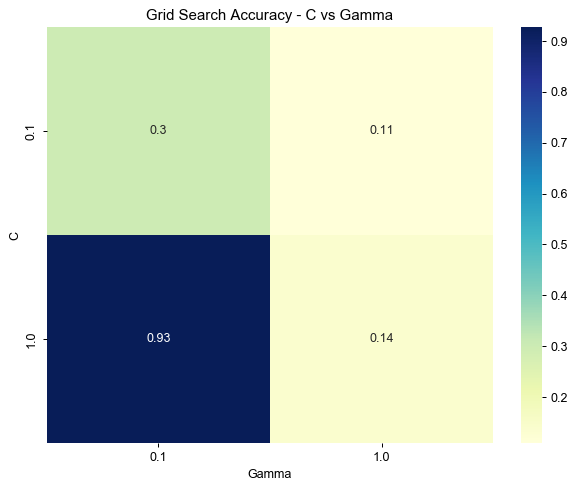

In [6]:
# 可视化不同 C 和 gamma 参数下的准确率
results = pd.DataFrame(grid_search.cv_results_)
scores_matrix = results.pivot(index="param_C", columns="param_gamma", values="mean_test_score")

plt.figure(figsize=(8, 6))
sns.heatmap(scores_matrix, annot=True, cmap="YlGnBu")
plt.title("Grid Search Accuracy - C vs Gamma")
plt.xlabel("Gamma")
plt.ylabel("C")
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_012.png)

我们已经通过网格搜索对超参数进行了优化，并使用 `StandardScaler` 对数据进行了标准化，确保模型在不同维度上表现一致。

可以进一步优化的方面包括：

1. **特征工程**：进一步探索特征提取或生成方法，可能会有助于提升模型性能。
2. **模型集成**：使用集成方法，如 bagging 或 boosting，将多个模型的预测结果结合，可以进一步提高分类精度。
3. **大规模并行化**：对于非常大的数据集，考虑使用 `sklearn` 的 `joblib` 或 `dask` 进行并行处理，减少计算时间。

## 应用场景

核函数主要适用于以下类型的问题：

1. **非线性分类问题**：当数据在原始空间中不可线性分割时，核函数通过将数据映射到高维空间，使得数据在新的空间中变得线性可分。
2. **非线性回归问题**：核函数同样可以应用于回归问题中，通过非线性映射，捕捉数据之间的复杂关系。
3. **降维与数据映射**：核函数可以用于降维技术（如核主成分分析），帮助在高维数据集中找到低维表示，同时保留数据中的重要结构。
4. **聚类与密度估计**：在无监督学习中，核函数可用于核密度估计和核聚类算法，如Spectral Clustering。

### 核函数的优缺点

#### 优点

1. **处理非线性问题**：核函数能够通过核技巧将原本线性不可分的问题转化为线性可分问题，从而处理复杂的非线性关系。
2. **灵活性高**：不同类型的核函数可以适应不同的应用场景，根据数据的特点选择合适的核函数能够提高模型性能。
3. **无需显式映射**：核函数通过计算内积直接在原始空间操作，而不需要显式地映射到高维空间，节省了计算资源。
4. **广泛应用**：核函数在多种算法中均有应用，如支持向量机、核岭回归、核主成分分析等。

#### 缺点

1. **计算复杂度高**：对于大规模数据集，核函数的计算复杂度较高，尤其是涉及到核矩阵的计算和存储时，可能会成为瓶颈。
2. **选择和调优难度大**：选择合适的核函数和超参数需要经验和大量实验，不同的核函数在不同的场景下效果差异较大。
3. **易过拟合**：如果选择的核函数和超参数不当，容易导致模型在训练数据上表现良好，但在测试数据上出现过拟合。

### 运用核函数的前提条件

1. **数据集的规模**：核函数在处理大规模数据集时会遇到计算瓶颈，因此在应用核函数前，需要考虑数据集的规模是否适合使用核函数。
2. **数据的非线性特点**：核函数适用于数据呈现出明显的非线性关系的情况，如果数据本身是线性可分的，则使用简单的线性模型可能更为有效。
3. **算法的计算资源**：由于核函数涉及到核矩阵的计算和存储，因此需要考虑算法是否有足够的计算资源和时间来完成这些操作。
4. **合适的核函数选择**：不同的核函数适用于不同的数据分布和问题类型，应用前需要对数据的特征和分布有一定的了解，以选择适当的核函数。

### 实际中的应用案例

**图像分类**：在图像分类中，支持向量机结合RBF核函数可以有效地处理复杂的图像特征。例如，在手写数字识别（如MNIST数据集）中，RBF核函数常用于将像素数据映射到更高维度的特征空间，从而提升分类准确率。

**自然语言处理**：在文本分类中，字符串核函数可以用于捕捉文本中的相似模式。例如，在垃圾邮件分类中，核函数帮助模型捕捉文本的语义信息，即使文本在表面上看似不同。

**生物信息学**：在基因序列分析中，核函数可以用于比较DNA序列之间的相似性。例如，在蛋白质结构预测中，核函数帮助捕捉序列中的复杂模式，提高预测精度。

**金融领域**：在金融时间序列预测中，核岭回归（Kernel Ridge Regression）结合RBF核函数可以用于捕捉股价或其他金融指标中的非线性趋势，从而提高预测精度。